In [1]:
# ══════════════════════════════════════════════════════════════════
# FAKE NEWS CLASSIFIER — Full Pipeline
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import json, re, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ══════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════════

df  = pd.read_csv("dataset/data.csv")
val = pd.read_csv("dataset/validation_data.csv")

print("── Training data ──────────────────────────")
print(df.shape)
print(df["label"].value_counts())
print(df.head(3))

print("\n── Validation data ────────────────────────")
print(val.shape)
print(val["label"].value_counts())   # should be all 2s
print(val.head(3))


── Training data ──────────────────────────
(39942, 5)
label
1    19999
0    19943
Name: count, dtype: int64
   label                                              title  \
0      1  As U.S. budget fight looms, Republicans flip t...   
1      1  U.S. military to accept transgender recruits o...   
2      1  Senior U.S. Republican senator: 'Let Mr. Muell...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   

── Validation data ────────────────────────
(4956, 5)
label
2    4956
Name: count, dtype: int64
   label                                              title  \
0      2  UK's May 'receiving regular updates' on London...   
1      2  UK transport police leading 

── Shape ───────────────────────────────────
(39942, 8)

── Data Types ──────────────────────────────
label          int64
title            str
text             str
subject          str
date             str
title_len      int64
text_len       int64
title_chars    int64
dtype: object

── Missing Values ──────────────────────────
label          0
title          0
text           0
subject        0
date           0
title_len      0
text_len       0
title_chars    0
dtype: int64

── Sample Rows ─────────────────────────────
   label                                              title  \
0      1  As U.S. budget fight looms, Republicans flip t...   
1      1  U.S. military to accept transgender recruits o...   
2      1  Senior U.S. Republican senator: 'Let Mr. Muell...   
3      1  FBI Russia probe helped by Australian diplomat...   
4      1  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - 

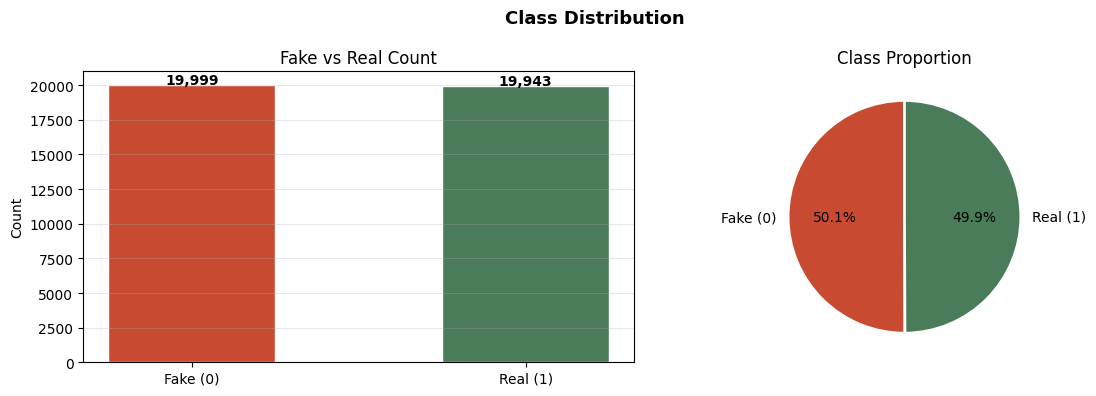

In [5]:
# ══════════════════════════════════════════════════════════════════
# 1. BASIC INFO
# ══════════════════════════════════════════════════════════════════

print("── Shape ───────────────────────────────────")
print(df.shape)

print("\n── Data Types ──────────────────────────────")
print(df.dtypes)

print("\n── Missing Values ──────────────────────────")
print(df.isnull().sum())

print("\n── Sample Rows ─────────────────────────────")
print(df.head(5))

print("\n── Label Distribution ──────────────────────")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

# ══════════════════════════════════════════════════════════════════
# 2. CLASS BALANCE
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution", fontsize=13, fontweight="bold")

# Count plot
counts = df["label"].value_counts()
colors = ["#c84b31", "#4a7c59"]
axes[0].bar(["Fake (0)", "Real (1)"], counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_ylabel("Count")
axes[0].set_title("Fake vs Real Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Pie chart
axes[1].pie(counts.values, labels=["Fake (0)", "Real (1)"],
            colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.savefig("results/eda_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()



── Title Length (words) ────────────────────
         count  mean  std  min   25%   50%   75%   max
label                                                 
0      19943.0  14.8  4.2  1.0  12.0  14.0  17.0  42.0
1      19999.0   9.9  1.7  4.0   9.0  10.0  11.0  20.0

── Text Length (words) ─────────────────────
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      19943.0  396.9  296.7  0.0  252.0  366.0  495.0  7033.0
1      19999.0  386.5  275.6  0.0  146.0  361.0  527.0  5172.0


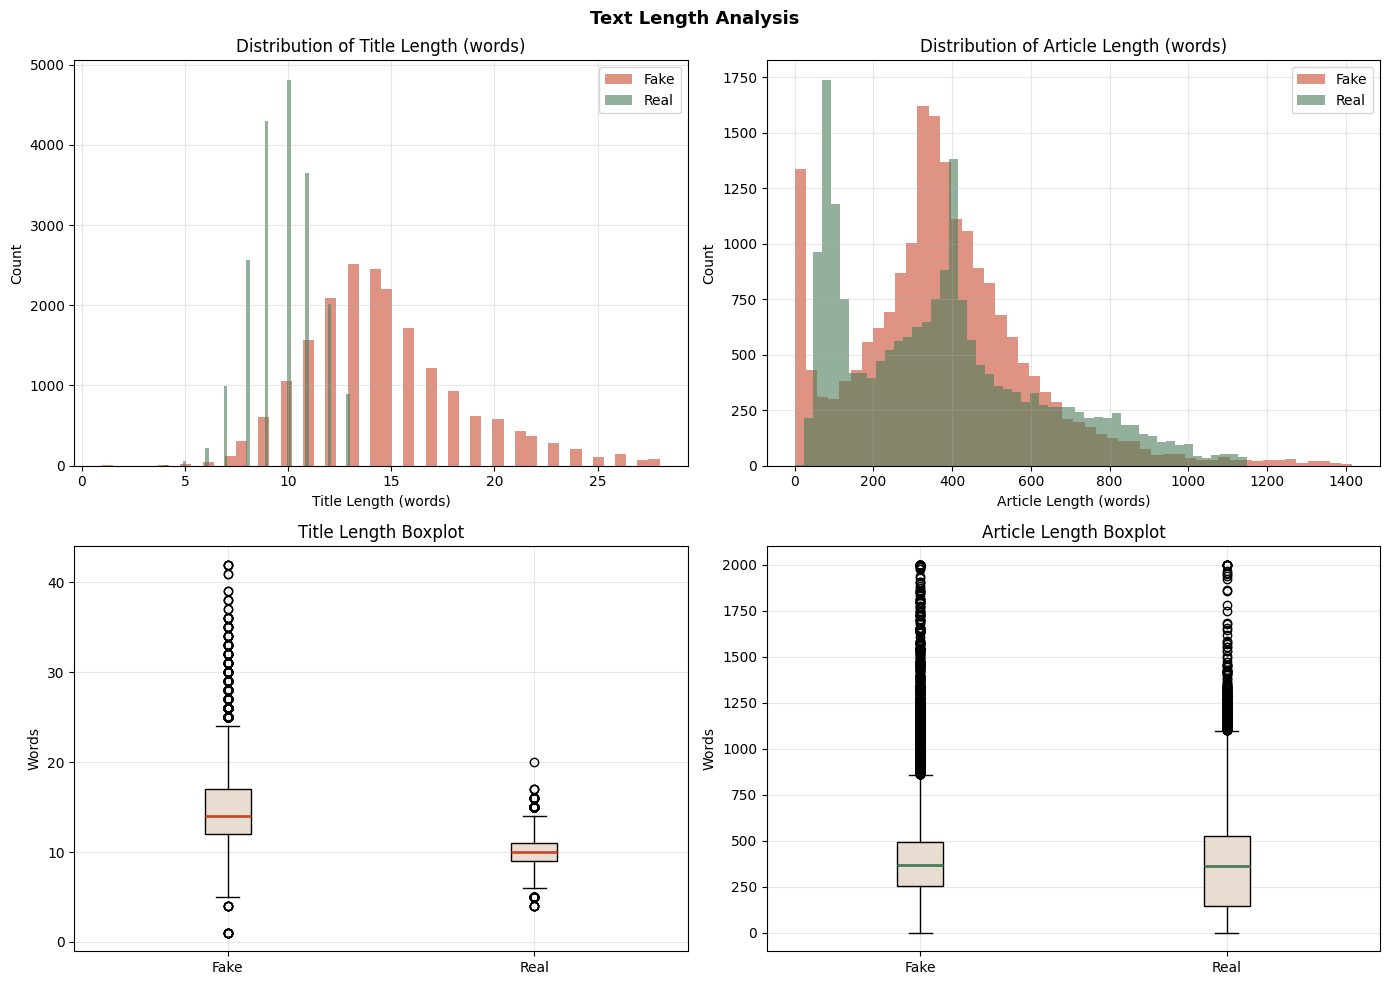


── Subjects ────────────────────────────────
subject
politicsNews       11272
News                9050
worldnews           8727
politics            6841
left-news           2482
Government News     1570
Name: count, dtype: int64


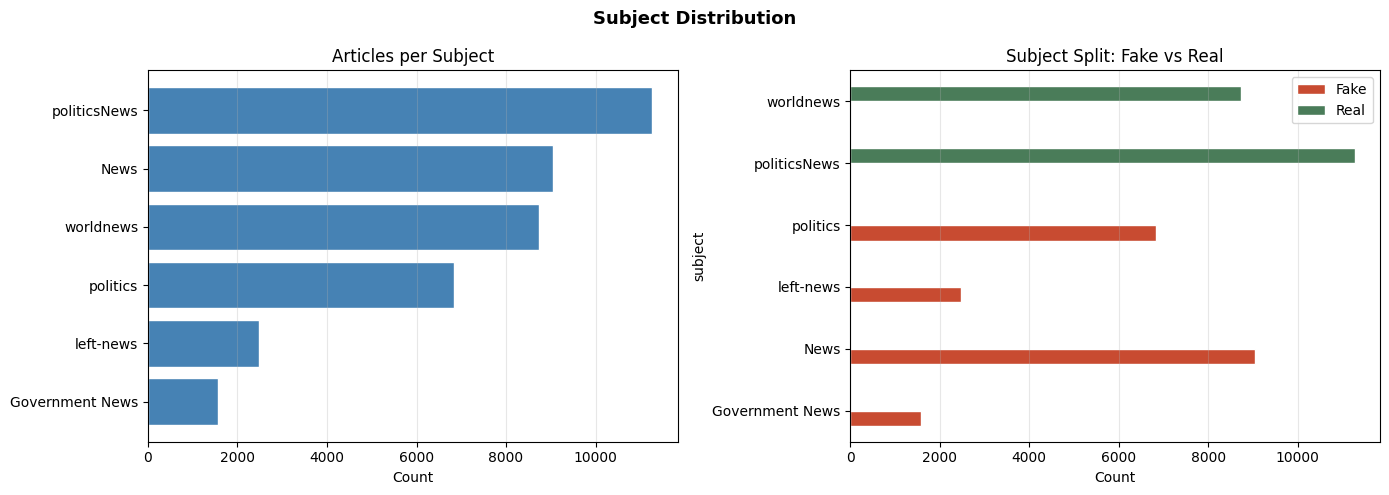

In [4]:
# ══════════════════════════════════════════════════════════════════
# 3. TEXT LENGTH ANALYSIS
# ══════════════════════════════════════════════════════════════════

df["title_len"]   = df["title"].fillna("").apply(lambda x: len(x.split()))
df["text_len"]    = df["text"].fillna("").apply(lambda x: len(x.split()))
df["title_chars"] = df["title"].fillna("").apply(len)

print("\n── Title Length (words) ────────────────────")
print(df.groupby("label")["title_len"].describe().round(1))

print("\n── Text Length (words) ─────────────────────")
print(df.groupby("label")["text_len"].describe().round(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Text Length Analysis", fontsize=13, fontweight="bold")

for ax, (col, title) in zip(axes.flatten(), [
    ("title_len",  "Title Length (words)"),
    ("text_len",   "Article Length (words)"),
]):
    for label, color, name in [(0, "#c84b31", "Fake"), (1, "#4a7c59", "Real")]:
        data = df[df["label"] == label][col]
        data = data[data < data.quantile(0.99)]  # remove extreme outliers for display
        ax.hist(data, bins=50, alpha=0.6, color=color, label=name, edgecolor="none")
    ax.set_xlabel(title); ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {title}")
    ax.legend(); ax.grid(alpha=0.3)

# Box plots
axes[1][0].boxplot(
    [df[df["label"]==0]["title_len"].clip(upper=50),
     df[df["label"]==1]["title_len"].clip(upper=50)],
    labels=["Fake", "Real"], patch_artist=True,
    boxprops=dict(facecolor="#e8ddd0"),
    medianprops=dict(color="#c84b31", linewidth=2)
)
axes[1][0].set_title("Title Length Boxplot"); axes[1][0].set_ylabel("Words")
axes[1][0].grid(alpha=0.3)

axes[1][1].boxplot(
    [df[df["label"]==0]["text_len"].clip(upper=2000),
     df[df["label"]==1]["text_len"].clip(upper=2000)],
    labels=["Fake", "Real"], patch_artist=True,
    boxprops=dict(facecolor="#e8ddd0"),
    medianprops=dict(color="#4a7c59", linewidth=2)
)
axes[1][1].set_title("Article Length Boxplot"); axes[1][1].set_ylabel("Words")
axes[1][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/eda_text_length.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════
# 4. SUBJECT / CATEGORY ANALYSIS
# ══════════════════════════════════════════════════════════════════

if "subject" in df.columns:
    print("\n── Subjects ────────────────────────────────")
    print(df["subject"].value_counts())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Subject Distribution", fontsize=13, fontweight="bold")

    # Overall subject counts
    subj_counts = df["subject"].value_counts()
    axes[0].barh(subj_counts.index[::-1], subj_counts.values[::-1],
                 color="steelblue", edgecolor="white")
    axes[0].set_title("Articles per Subject")
    axes[0].set_xlabel("Count")
    axes[0].grid(axis="x", alpha=0.3)

    # Subject split by fake vs real
    subj_label = df.groupby(["subject", "label"]).size().unstack(fill_value=0)
    subj_label.columns = ["Fake", "Real"]
    subj_label.plot(kind="barh", ax=axes[1], color=["#c84b31", "#4a7c59"],
                    edgecolor="white")
    axes[1].set_title("Subject Split: Fake vs Real")
    axes[1].set_xlabel("Count")
    axes[1].legend()
    axes[1].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/eda_subjects.png", dpi=150, bbox_inches="tight")
    plt.show()

In [6]:
# ══════════════════════════════════════════════════════════════════
# 5. Prepare the text feature

# The model cannot learn directly from raw strings. We create one feature called "combined_text" by joining title + text
# Also apply .fillna("") to avoid problems with missing values
# ══════════════════════════════════════════════════════════════════

# create combined text for training data
df["combined_text"] = (df["title"].fillna("") + "" + df["text"].fillna("")).str.strip()

# create combined text for validation data
val["combined_text"] = (val["title"].fillna("") + "" + val["text"].fillna("")).str.strip()


print("Training combined text examples:")
display(df[["title", "text", "combined_text", "label"]].head(3))

print("Validation combined text examples:")
display(val[["title", "text", "combined_text", "label"]].head(3))


Training combined text examples:


,title,text,combined_text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,Senior U.S. Republican senator: 'Let Mr. Muell...,1


Validation combined text examples:


,title,text,combined_text,label
0,UK's May 'receiving regular updates' on London...,LONDON (Reuters) - British Prime Minister Ther...,UK's May 'receiving regular updates' on London...,2
1,UK transport police leading investigation of L...,LONDON (Reuters) - British counter-terrorism p...,UK transport police leading investigation of L...,2
2,Pacific nations crack down on North Korean shi...,WELLINGTON (Reuters) - South Pacific island na...,Pacific nations crack down on North Korean shi...,2


In [7]:
# ══════════════════════════════════════════════════════════════════
# 6. Define X and y

# X => features used by the model to learn => combined_text
# y => target label we want to predict => label

# The validation file is not used for training because its labels are unknown (2)
# ══════════════════════════════════════════════════════════════════

X = df["combined_text"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:")
print(y.value_counts())

X shape: (39942,)
y shape: (39942,)
Labels:
label
1    19999
0    19943
Name: count, dtype: int64


In [10]:
# ══════════════════════════════════════════════════════════════════
# 7. Train/Test Split

# 80% training data
# 20% test data

# stratify = y keeps the class propotion similar in both sets. This avoids accidentally creating a training or test set with an unbalanced label distribution.

# ══════════════════════════════════════════════════════════════════

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state=42, stratify=y)

print("Train:" , X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).round(4))


Train: (31953,) (31953,)
Test: (7989,) (7989,)

Train label distribution:
label
1    0.5007
0    0.4993
Name: proportion, dtype: float64

Test label distribution:
label
1    0.5007
0    0.4993
Name: proportion, dtype: float64


In [11]:
# ══════════════════════════════════════════════════════════════════
# 8. TF-IDF vectorization

# TF-IDF transforms text into a nunmerical matrix

# ══════════════════════════════════════════════════════════════════

# Demonstrating only: the final model will include TF-IDF inside a Pipeline

tfidf_demo = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf_demo = tfidf_demo.fit_transform(X_train)
X_test_tfidf_demo = tfidf_demo.transform(X_test)

print("Train TF-IDF matrix shape:", X_train_tfidf_demo.shape)
print("Test IF-IDF matrix shape:", X_test_tfidf_demo.shape)

Train TF-IDF matrix shape: (31953, 50000)
Test IF-IDF matrix shape: (7989, 50000)


In [18]:
# ══════════════════════════════════════════════════════════════════
# 9. Train and compare several models
# ══════════════════════════════════════════════════════════════════

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear", random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
trained_pipelines = {}

for model_name, classifier in models.items():
    print(f"\nTraining: {model_name}")

    pipeline = Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    lowercase=True,
                    max_features=50000,
                    ngram_range=(1,2),
                    min_df=2,
                    max_df=0.95
                )
            ),
            ("classifier", classifier)
        ]
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    # ROC AUC only if the model supports predict_proba
    roc_auc = np.nan
    if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
        try:
            y_proba = pipeline.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)
        except Exception:
            roc_auc = np.nan

    results.append({
        "model": model_name,
        "accuracy": acc,
        "roc_auc": roc_auc
    })

    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
results_df




Training: Logistic Regression

Training: Multinomial Naive Bayes

Training: Random Forest

Training: Gradient Boosting


,model,accuracy,roc_auc
0,Gradient Boosting,0.995869,0.999605
1,Random Forest,0.994367,0.999810
2,Logistic Regression,0.984479,0.998836
3,Multinomial Naive Bayes,0.949556,0.987949


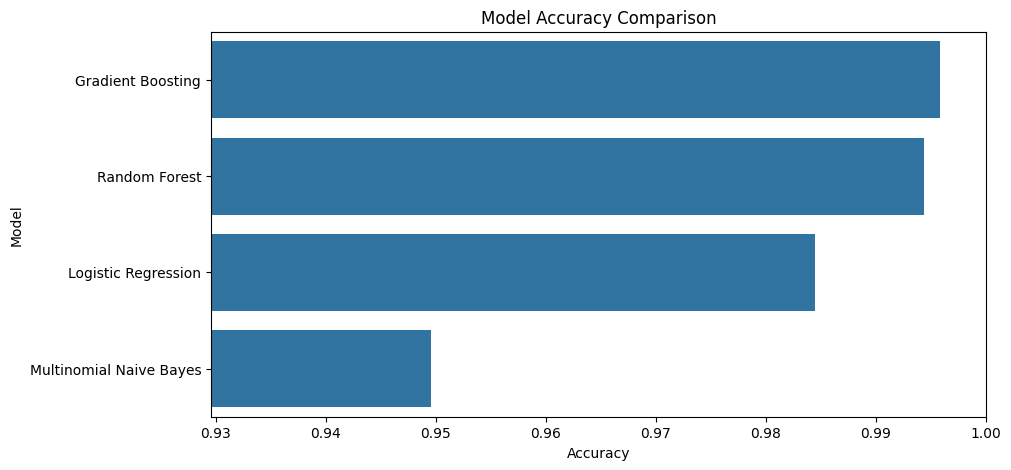

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 10. Visualize model comparison
# ══════════════════════════════════════════════════════════════════

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="accuracy", y="model")
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(max(0, results_df["accuracy"].min()-0.02), 1.0)
plt.show()

In [22]:
# ══════════════════════════════════════════════════════════════════
# 11. Select the best model => Model with highest test accuracy
# ══════════════════════════════════════════════════════════════════

best_model_name = results_df.loc[0, "model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model:", best_model_name)
print("Best accuracy:", results_df.loc[0, "accuracy"])


Best model: Gradient Boosting
Best accuracy: 0.9958693203154337


Best model:, Gradient Boosting
Accuracy:, 0.9959

Confusion Matrix:
[[3968   21]
 [  12 3988]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9970    0.9947    0.9959      3989
           1     0.9948    0.9970    0.9959      4000

    accuracy                         0.9959      7989
   macro avg     0.9959    0.9959    0.9959      7989
weighted avg     0.9959    0.9959    0.9959      7989



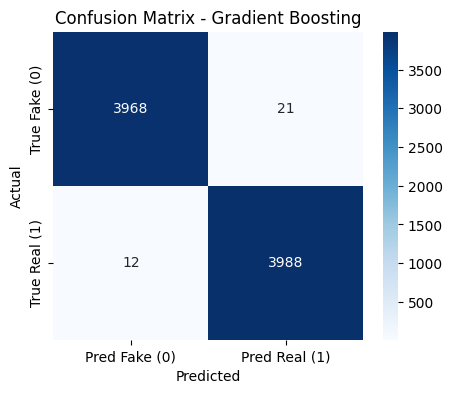

In [23]:
# ══════════════════════════════════════════════════════════════════
# 12. Detailed Evaluation of the best model

# Use of accuracy, confusion matrix and classification report => Inspect the best model 
# ══════════════════════════════════════════════════════════════════

best_y_pred = best_pipeline.predict(X_test)

print(f"Best model:, {best_model_name}")
print(f"Accuracy:, {accuracy_score(y_test, best_y_pred):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, best_y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, best_y_pred, digits=4))

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Fake (0)", "Pred Real (1)"],
    yticklabels=["True Fake (0)", "True Real (1)"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
